In [30]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping



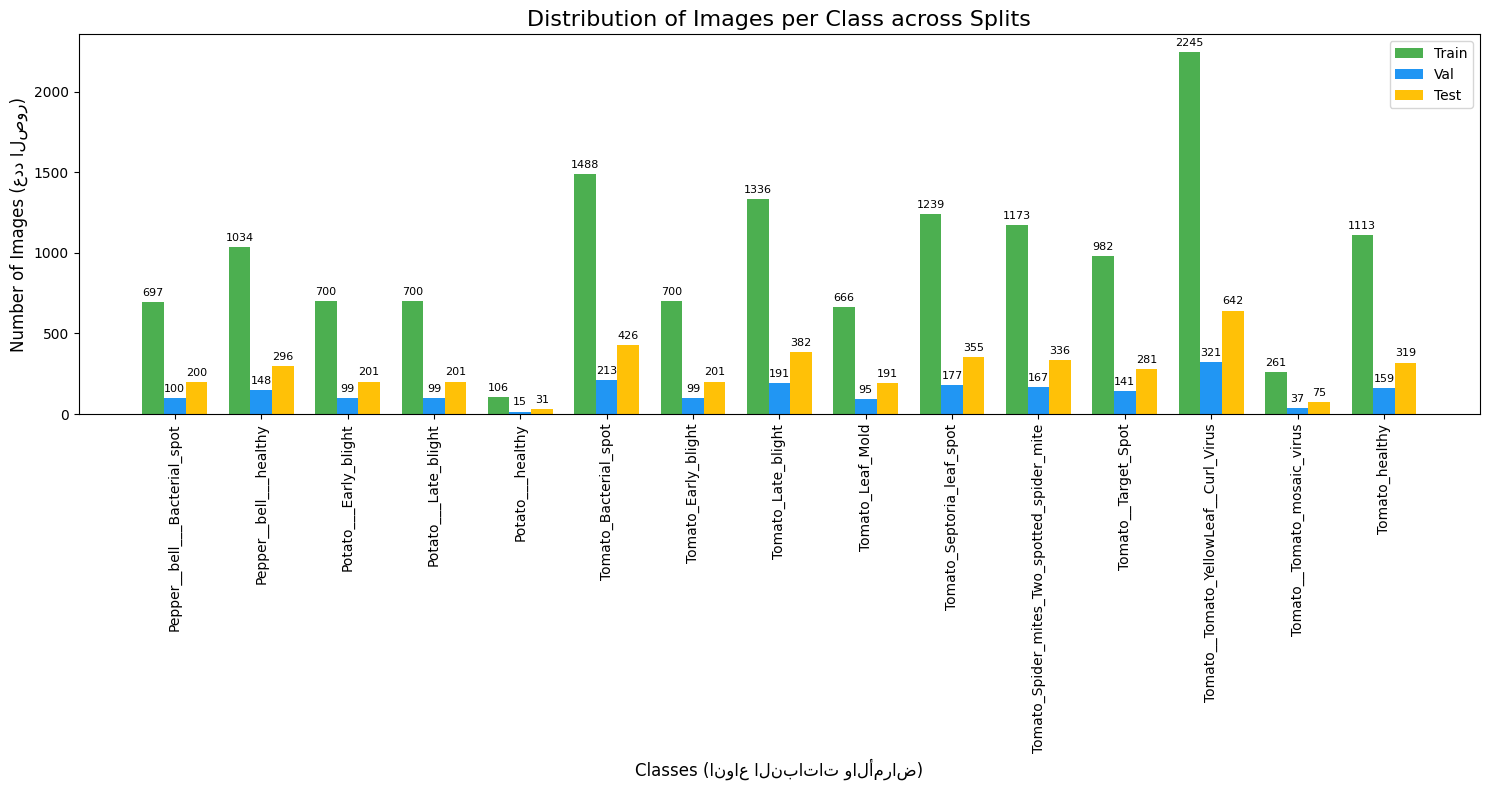

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt

# المسار الرئيسي للمجلد المقسم
base_dir = "PlantVillage_Split"
splits = ['train', 'val', 'test']

# الحصول على أسماء الكلاسات (مرتبة أبجدياً)
classes = sorted(os.listdir(os.path.join(base_dir, 'train')))

# تجميع البيانات
counts = {split: [] for split in splits}
for split in splits:
    for cls in classes:
        path = os.path.join(base_dir, split, cls)
        counts[split].append(len(os.listdir(path)))

# إعداد الرسم البياني
x = np.arange(len(classes))  # مواقع الكلاسات على المحور الأفقي
width = 0.25  # عرض العمود الواحد

fig, ax = plt.subplots(figsize=(15, 8))

# رسم الأعمدة لكل قسم
rects1 = ax.bar(x - width, counts['train'], width, label='Train', color='#4CAF50')
rects2 = ax.bar(x, counts['val'], width, label='Val', color='#2196F3')
rects3 = ax.bar(x + width, counts['test'], width, label='Test', color='#FFC107')

# إضافة النصوص والعناوين
ax.set_xlabel('Classes (انواع النباتات والأمراض)', fontsize=12)
ax.set_ylabel('Number of Images (عدد الصور)', fontsize=12)
ax.set_title('Distribution of Images per Class across Splits', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=90) # تدوير الأسماء لسهولة القراءة
ax.legend()

# إضافة الأرقام فوق الأعمدة (اختياري، قد يسبب زحاماً إذا كان عدد الكلاسات كبيراً)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # إزاحة للأعلى بـ 3 نقاط
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()

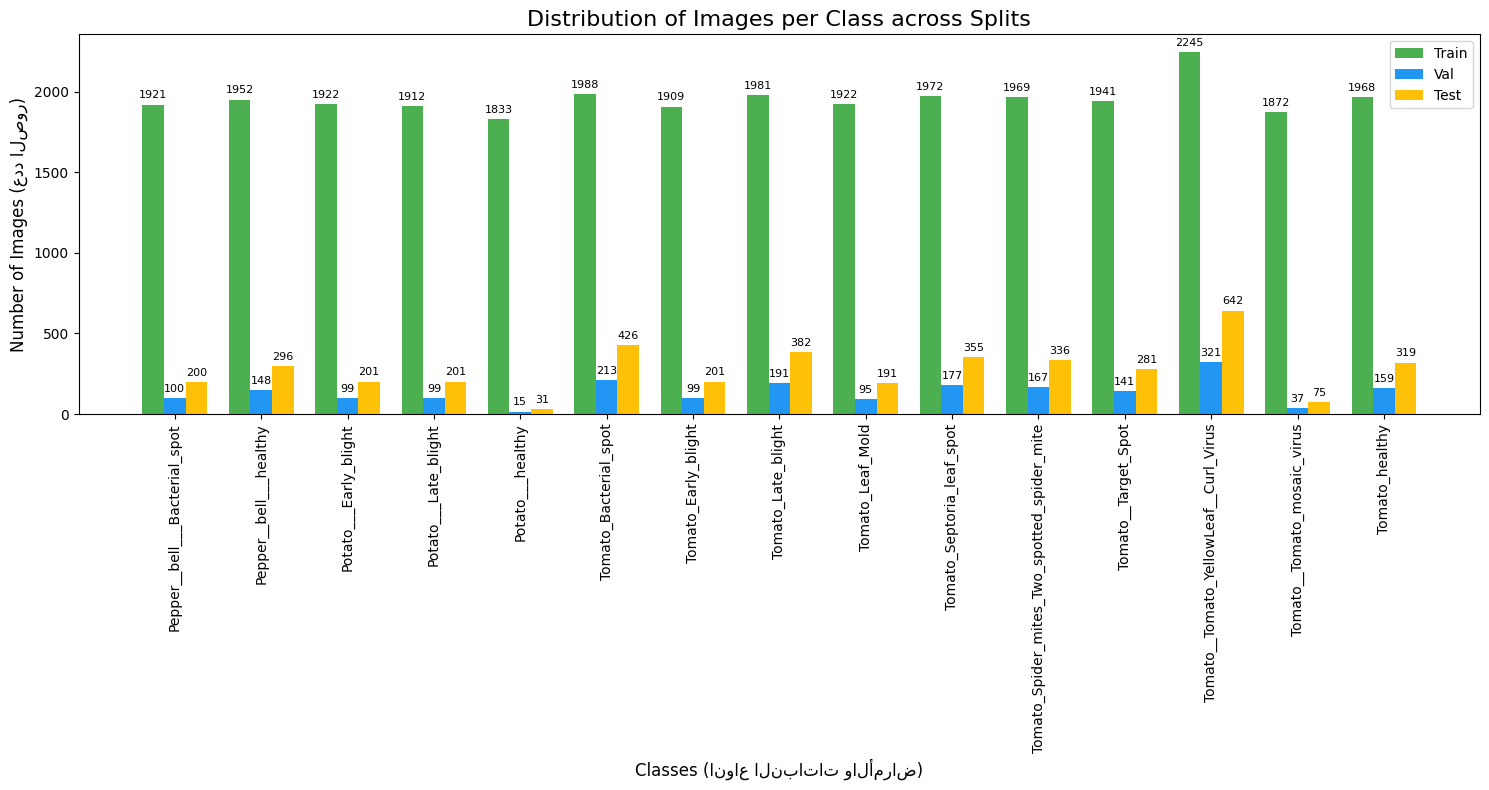

In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt

# المسار الرئيسي للمجلد المقسم
base_dir = "PlantVillage_Split"
splits = ['train_balanced', 'val', 'test']

# الحصول على أسماء الكلاسات (مرتبة أبجدياً)
classes = sorted(os.listdir(os.path.join(base_dir, 'train')))

# تجميع البيانات
counts = {split: [] for split in splits}
for split in splits:
    for cls in classes:
        path = os.path.join(base_dir, split, cls)
        counts[split].append(len(os.listdir(path)))

# إعداد الرسم البياني
x = np.arange(len(classes))  # مواقع الكلاسات على المحور الأفقي
width = 0.25  # عرض العمود الواحد

fig, ax = plt.subplots(figsize=(15, 8))

# رسم الأعمدة لكل قسم
rects1 = ax.bar(x - width, counts['train_balanced'], width, label='Train', color='#4CAF50')
rects2 = ax.bar(x, counts['val'], width, label='Val', color='#2196F3')
rects3 = ax.bar(x + width, counts['test'], width, label='Test', color='#FFC107')

# إضافة النصوص والعناوين
ax.set_xlabel('Classes (انواع النباتات والأمراض)', fontsize=12)
ax.set_ylabel('Number of Images (عدد الصور)', fontsize=12)
ax.set_title('Distribution of Images per Class across Splits', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=90) # تدوير الأسماء لسهولة القراءة
ax.legend()

# إضافة الأرقام فوق الأعمدة (اختياري، قد يسبب زحاماً إذا كان عدد الكلاسات كبيراً)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # إزاحة للأعلى بـ 3 نقاط
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()

In [6]:
BATCH_SIZE = 15
IMAGE_SIZE = 128
CHANNELS=3
EPOCHS=50

In [7]:
# 1. تحميل المجموعات الثلاث
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:\\Users\\USER\\Desktop\\450data\\PlantVillage_Split\\train_balanced",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)


Found 29307 files belonging to 15 classes.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:\\Users\\USER\\Desktop\\450data\\PlantVillage_Split\\val",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2061 files belonging to 15 classes.


In [34]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "C:\\Users\\USER\\Desktop\\450data\\PlantVillage_Split\\test",
    seed=123,
    shuffle=True, # لا نحتاج للخلط في التست
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 4137 files belonging to 15 classes.


In [8]:
class_names = train_ds.class_names
class_names

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [40]:
len(class_names)

15

In [42]:
for image_batch, labels_batch in train_ds.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(15, 128, 128, 3)
[ 8 10  7 14  7 12  8 13  8  4  0 13  6  7 11]


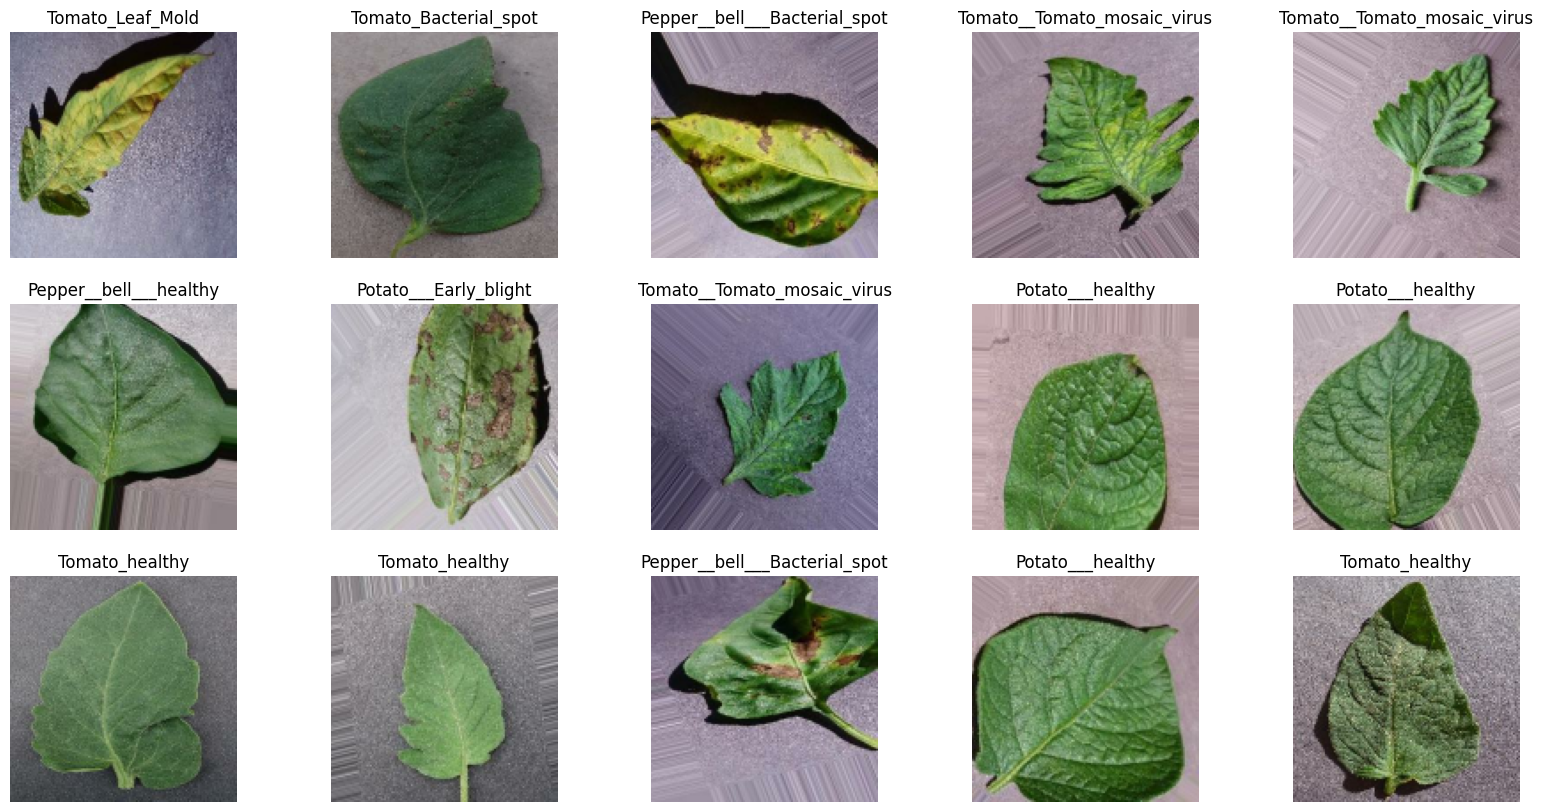

In [43]:
plt.figure(figsize=(20, 10))
for image_batch, labels_batch in train_ds.take(1):
    for i in range(15):
        ax = plt.subplot(3, 5, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [44]:
len(train_ds), len(val_ds), len(test_ds)

(1954, 138, 276)

In [15]:
"""
def get_dataset_partitions_tf(ds, train_split=0.7, val_split=0.2, test_split=0.1, shuffle=True, shuffle_size=5000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12, reshuffle_each_iteration=False)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds
"""

'\ndef get_dataset_partitions_tf(ds, train_split=0.7, val_split=0.2, test_split=0.1, shuffle=True, shuffle_size=5000):\n    assert (train_split + test_split + val_split) == 1\n\n    ds_size = len(ds)\n\n    if shuffle:\n        ds = ds.shuffle(shuffle_size, seed=12, reshuffle_each_iteration=False)\n\n    train_size = int(train_split * ds_size)\n    val_size = int(val_split * ds_size)\n\n    train_ds = ds.take(train_size)    \n    val_ds = ds.skip(train_size).take(val_size)\n    test_ds = ds.skip(train_size).skip(val_size)\n\n    return train_ds, val_ds, test_ds\n'

In [45]:
#train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)
train_ds = train_ds.shuffle(1000, seed=12 ,reshuffle_each_iteration=True)


In [46]:
len(train_ds)

1954

In [47]:
len(val_ds)

138

Prefetch the Dataset


In [48]:
train_ds = train_ds.prefetch(1) # for no wating to next batch & and dont change the data value 
val_ds   = val_ds.prefetch(1)
test_ds  = test_ds.prefetch(1)


Building the Model


In [49]:
n_classes = 15

model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)), 
    layers.Rescaling(1./255), 

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(), 

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),    
    
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.GlobalAveragePooling2D(), # it wrok as flaten + 128

    layers.Dropout(0.3),

    layers.Dense(n_classes, activation="softmax"),
])

early_stop = EarlyStopping(
    monitor='val_loss',  
    patience=5,              
    restore_best_weights=True
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,271 (1.50 MB)

 Trainable params: 392,271 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [51]:
model.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(),  
    metrics=['accuracy']
)

In [52]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=50,
    callbacks=[early_stop],
)

Epoch 1/50
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 214s 82ms/step - accuracy: 0.4334 - loss: 1.6970 - val_accuracy: 0.7336 - val_loss: 0.7742
Epoch 2/50
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 147s 74ms/step - accuracy: 0.7389 - loss: 0.7826 - val_accuracy: 0.8253 - val_loss: 0.5222
Epoch 3/50
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 150s 75ms/step - accuracy: 0.8264 - loss: 0.5222 - val_accuracy: 0.8957 - val_loss: 0.3234
Epoch 4/50
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 147s 74ms/step - accuracy: 0.8673 - loss: 0.4032 - val_accuracy: 0.9156 - val_loss: 0.2657
Epoch 5/50
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 148s 74ms/step - accuracy: 0.8906 - loss: 0.3320 - val_accuracy: 0.9151 - val_loss: 0.2443
Epoch 6/50
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 148s 74ms/step - accuracy: 0.9062 - loss: 0.2803 - val_accuracy: 0.9413 - val_loss: 0.1650
Epoch 7/50
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 154s 78ms/step - accuracy: 0.9181 - loss: 0.2476 - val_accuracy: 0.9476 - val_loss: 0.1580
Epoch 8/50
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 155s 78ms/step - accuracy: 

In [64]:
scores = model.evaluate(test_ds)


276/276 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9763 - loss: 0.0695


In [65]:
scores

[0.06951702386140823, 0.9763113260269165]

Plotting the Accuracy and Loss Curves


In [66]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

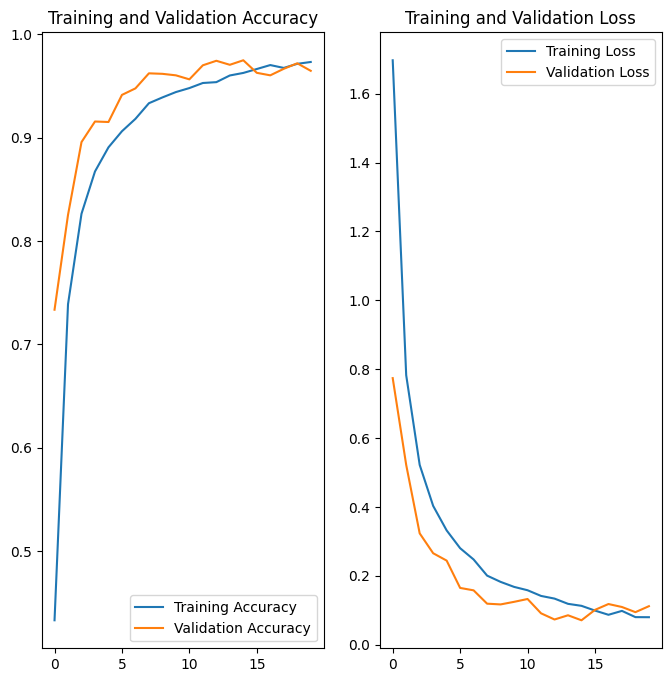

In [67]:
EPOCHS= 20
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Run prediction on a sample image


first image to predict
actual label: Tomato__Tomato_YellowLeaf__Curl_Virus
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
predicted label: Tomato__Tomato_YellowLeaf__Curl_Virus


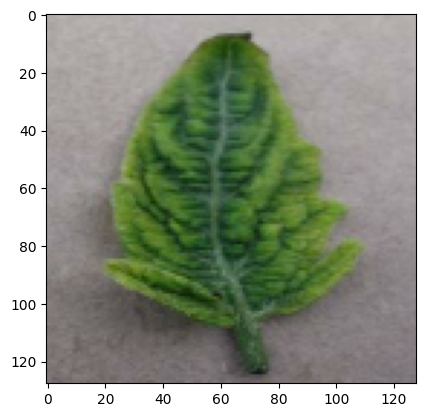

In [68]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [59]:
import os

save_dir = r"C:\\Users\\USER\\Desktop\\450data\\model" 

# إنشاء المجلد إذا لم يكن موجوداً
os.makedirs(save_dir, exist_ok=True)

existing = [
    int(f.split(".")[0]) 
    for f in os.listdir(save_dir) 
    if f.endswith(".keras") and f.split(".")[0].isdigit()
]

model_version = max(existing + [0]) + 1

full_save_path = os.path.join(save_dir, f"{model_version}.keras")

model.save(full_save_path)

print(f"Model saved successfully!")
print(f"Location: {full_save_path}")

Model saved successfully!
Location: C:\\Users\\USER\\Desktop\\450data\\model\3.keras


In [1]:
import os
import tensorflow as tf

# حدد المجلد الذي وضعت فيه الموديل
model_path = r"C:\\Users\\USER\\Desktop\\450data\\tries\\try2\\3.keras" 

if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)
    print("تم تحميل الموديل بنجاح")
else:
    print("الملف غير موجود في المسار المحدد!")

c:\Users\USER\miniconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


تم تحميل الموديل بنجاح


In [36]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)

    return predicted_class, confidence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


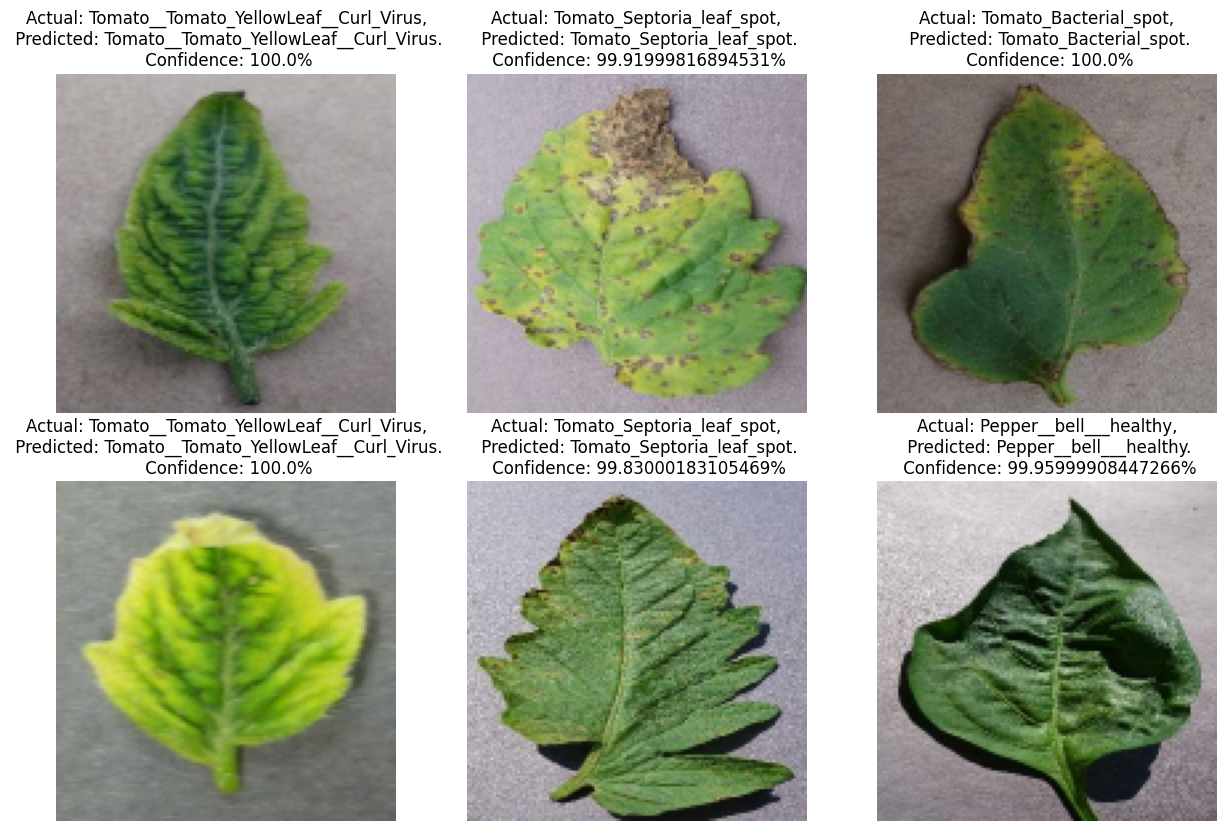

In [37]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(6):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted class: Potato___Early_blight
Confidence: 100.0 %


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

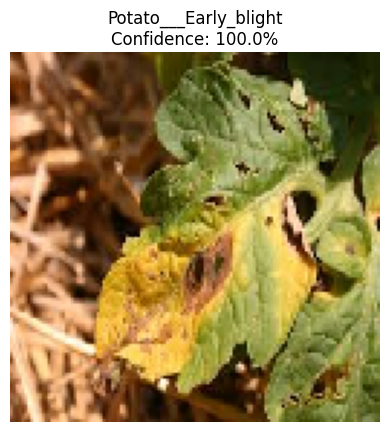

In [12]:
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np


IMAGE_SIZE = 128  

# ===== 4) load_img  =====
img = tf.keras.preprocessing.image.load_img(
    r"C:\\Users\\USER\\Desktop\\450data\\New folder\\WhatsApp Image 2026-01-01 at 2.48.37 PM.jpeg", 
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

# ===== 5) preprocessing_image  =====
img_array = tf.keras.preprocessing.image.img_to_array(img)       
img_array = tf.expand_dims(img_array, 0)

# ===== 6) predictions =====
predictions = model.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = round(100 * np.max(predictions[0]), 2)

# ===== 7) predicted_class  =====
print("Predicted class:", predicted_class)
print("Confidence:", confidence, "%")

plt.imshow(img)
plt.title(f"{predicted_class}\nConfidence: {confidence}%")
plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted class: Tomato_Spider_mites_Two_spotted_spider_mite
Confidence: 99.98 %


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

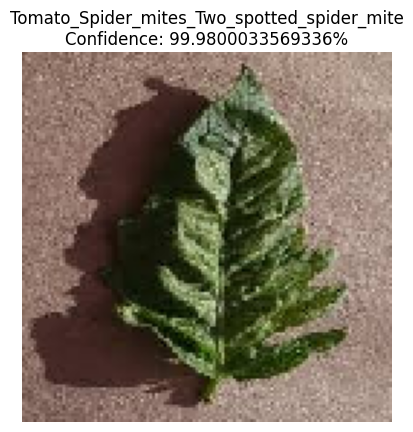

In [13]:
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np


IMAGE_SIZE = 128  

# ===== 4) load_img  =====
img = tf.keras.preprocessing.image.load_img(
    r"C:\\Users\\USER\\Desktop\\450data\\New folder\\WhatsApp Image 2026-01-01 at 2.48.42 PM.jpeg", 
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

# ===== 5) preprocessing_image  =====
img_array = tf.keras.preprocessing.image.img_to_array(img)       
img_array = tf.expand_dims(img_array, 0)

# ===== 6) predictions =====
predictions = model.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = round(100 * np.max(predictions[0]), 2)

# ===== 7) predicted_class  =====
print("Predicted class:", predicted_class)
print("Confidence:", confidence, "%")

plt.imshow(img)
plt.title(f"{predicted_class}\nConfidence: {confidence}%")
plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted class: Pepper__bell___Bacterial_spot
Confidence: 100.0 %


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

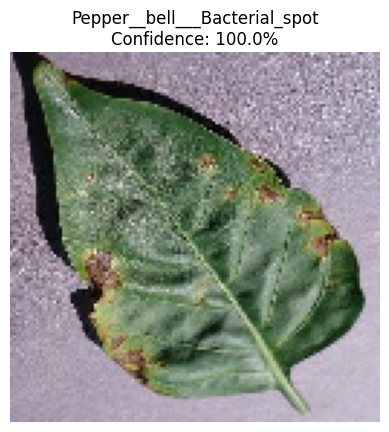

In [15]:
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np


IMAGE_SIZE = 128  

# ===== 4) load_img  =====
img = tf.keras.preprocessing.image.load_img(
    r"C:\\Users\\USER\\Desktop\\450data\\New folder\\00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Spot 3132.JPG", 
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

# ===== 5) preprocessing_image  =====
img_array = tf.keras.preprocessing.image.img_to_array(img)       
img_array = tf.expand_dims(img_array, 0)

# ===== 6) predictions =====
predictions = model.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = round(100 * np.max(predictions[0]), 2)

# ===== 7) predicted_class  =====
print("Predicted class:", predicted_class)
print("Confidence:", confidence, "%")

plt.imshow(img)
plt.title(f"{predicted_class}\nConfidence: {confidence}%")
plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted class: Tomato_Early_blight
Confidence: 99.75 %


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

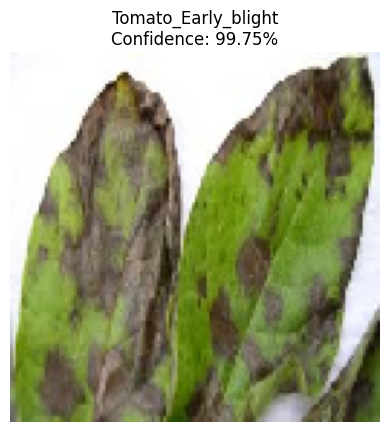

In [16]:
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np


IMAGE_SIZE = 128  

# ===== 4) load_img  =====
img = tf.keras.preprocessing.image.load_img(
    r"C:\\Users\\USER\\Desktop\\450data\\New folder\\images.jpeg", 
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

# ===== 5) preprocessing_image  =====
img_array = tf.keras.preprocessing.image.img_to_array(img)       
img_array = tf.expand_dims(img_array, 0)

# ===== 6) predictions =====
predictions = model.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = round(100 * np.max(predictions[0]), 2)

# ===== 7) predicted_class  =====
print("Predicted class:", predicted_class)
print("Confidence:", confidence, "%")

plt.imshow(img)
plt.title(f"{predicted_class}\nConfidence: {confidence}%")
plt.axis("off")